In [1]:
# Option A: Simple install
#!pip install requests pandas matplotlib  ta-lib

📈 BACKTEST: 601126.SS
Initial Capital ($)    : 10000
Final Capital ($)      : 16309.91
Total Return (%)       : 63.1
Closed Trades          : 2
Win Rate (%)           : 50.0
Net Profit ($)         : 6310.41

📋 TRADE LOG:
--------------------------------------------------
2026-04-14 | BUY  | Price:    43.68 | Shares:  228 | Fee:   9.96
2026-05-28 | SELL | Price:    82.02 | Shares:  228 | Fee:  18.70
2026-06-18 | BUY  | Price:    74.63 | Shares:  250 | Fee:  18.66
2026-06-26 | SELL | Price:    65.16 | Shares:  250 | Fee:  16.29


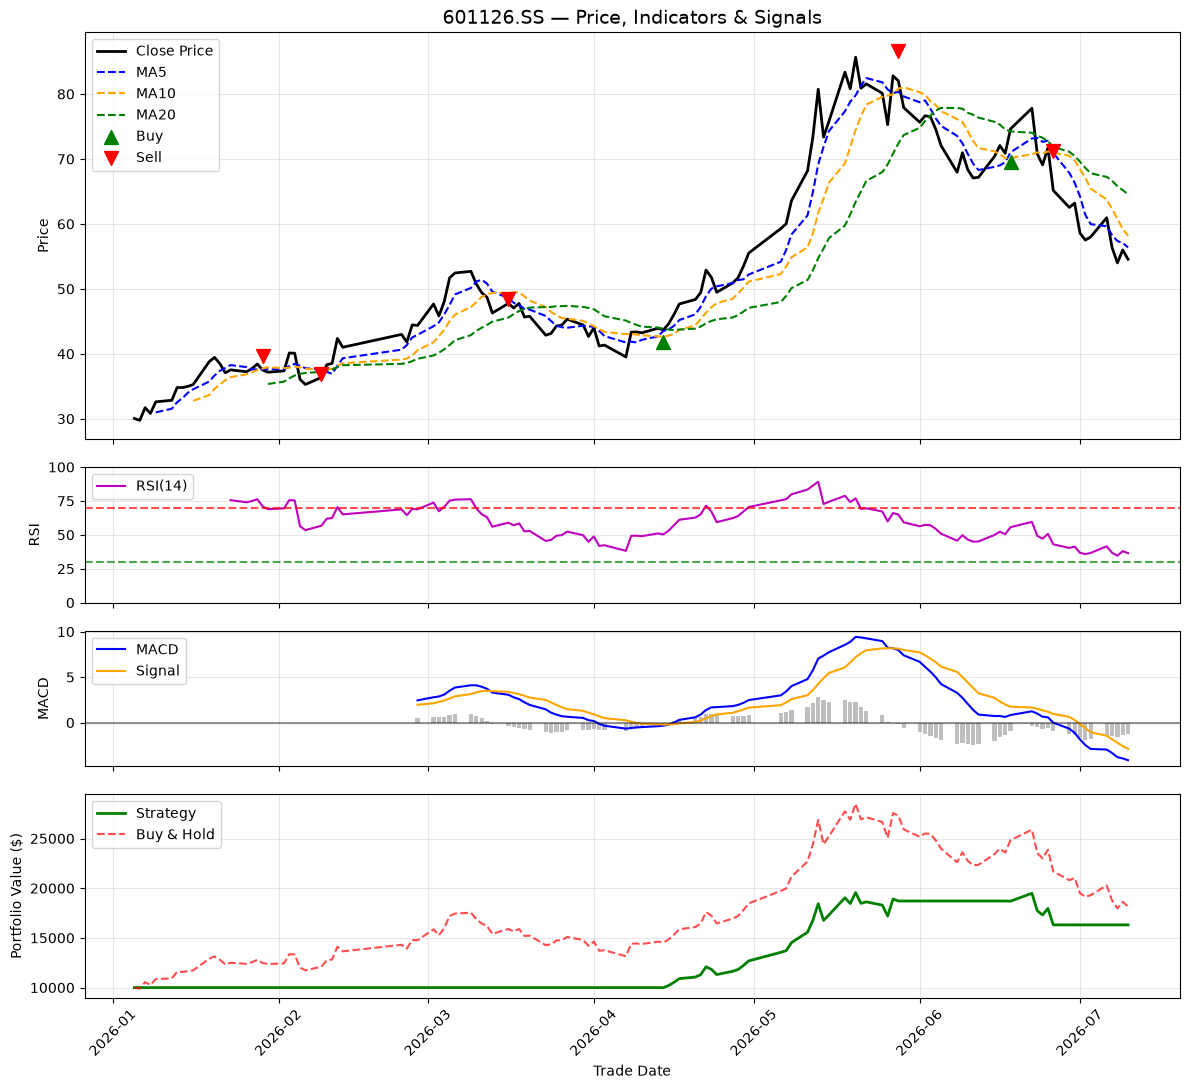


✅ Saved to: data/601126.SS_*.csv


({'Initial Capital ($)': 10000,
  'Final Capital ($)': 16309.91,
  'Total Return (%)': 63.1,
  'Closed Trades': 2,
  'Win Rate (%)': 50.0,
  'Net Profit ($)': 6310.41},
 Price trade_date       open       high        low      close       vol  \
 0     2026-01-05  30.042663  30.547832  29.349294  30.052568  24809387   
 1     2026-01-06  30.092189  30.339821  29.527589  29.745506  24147855   
 2     2026-01-07  29.735600  31.855326  29.527588  31.706745  37029084   
 3     2026-01-08  31.498736  32.816138  30.627074  30.825180  30220496   
 4     2026-01-09  30.656790  32.885474  30.636979  32.608124  33554640   
 ..           ...        ...        ...        ...        ...       ...   
 119   2026-07-06  58.880001  62.669998  58.730000  60.959999  28867124   
 120   2026-07-07  61.939999  61.939999  56.000000  56.389999  24603080   
 121   2026-07-08  56.980000  57.770000  53.900002  54.000000  23026696   
 122   2026-07-09  54.630001  56.279999  52.700001  56.000000  25697667   
 123  

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import talib

# ==============================================
# 📋 CONFIG — CHANGE ONLY THESE 4 LINES
# ==============================================
# Pick any ticker from the list below
# TICKER = "600519.SS"       # Guizhou Maotai
TICKER = "601126.SS"       # Guizhou Maotai
START_DATE = "2026-01-01"
END_DATE = "2026-07-13"
INITIAL_CAPITAL = 10000
TRANSACTION_FEE_RATE = 0.001  # 0.1% per trade

os.makedirs("data", exist_ok=True)

# ==============================================
# 🚀 CORE FUNCTION — WORKS FOR ALL STOCKS
# ==============================================
def run_strategy(ticker, start, end, capital, fee_rate):
    # 1. Fetch & clean data
    df = yf.download(ticker, start=start, end=end, progress=False)
    if df.empty:
        print(f"❌ No data found for {ticker}. Check ticker format!")
        return None, None, None

    df = df.droplevel("Ticker", axis=1).reset_index()
    df = df.rename(columns={
        "Date": "trade_date", "Open": "open", "High": "high",
        "Low": "low", "Close": "close", "Volume": "vol"
    })
    df = df[["trade_date", "open", "high", "low", "close", "vol"]]
    df["trade_date"] = pd.to_datetime(df["trade_date"])
    df = df.sort_values("trade_date").reset_index(drop=True)

    # 2. Calculate indicators
    close = df["close"].values
    df["MA5"] = talib.SMA(close, 5)
    df["MA10"] = talib.SMA(close, 10)
    df["MA20"] = talib.SMA(close, 20)
    df["RSI"] = talib.RSI(close, 14)
    macd, macd_signal, macd_hist = talib.MACD(close, 12, 26, 9)
    df["MACD"], df["MACD_Signal"], df["MACD_Hist"] = macd, macd_signal, macd_hist

    # 3. Generate buy/sell signals
    df["Buy_Signal"] = 0.0
    df["Sell_Signal"] = 0.0
    for i in range(1, len(df)):
        if (df["MA5"].iloc[i] > df["MA10"].iloc[i] and
            df["MA5"].iloc[i-1] <= df["MA10"].iloc[i-1] and
            df["RSI"].iloc[i] < 70):
            df.loc[i, "Buy_Signal"] = df["low"].iloc[i] * 0.99

        if (df["MA5"].iloc[i] < df["MA10"].iloc[i] and
            df["MA5"].iloc[i-1] >= df["MA10"].iloc[i-1] and
            df["RSI"].iloc[i] > 30):
            df.loc[i, "Sell_Signal"] = df["high"].iloc[i] * 1.01

    # 4. Backtest
    def backtest(data, initial_cap, fee):
        cap = float(initial_cap)
        shares = 0
        position = 0
        trades = []
        bt_df = data.copy()
        bt_df["Position"] = 0
        bt_df["Portfolio_Value"] = 0.0

        for i in range(len(bt_df)):
            price = float(bt_df["close"].iloc[i])
            date = bt_df["trade_date"].iloc[i]

            if bt_df["Buy_Signal"].iloc[i] > 0 and position == 0:
                shares = int(cap // price)
                if shares == 0:
                    continue
                cost = shares * price
                trading_fee = cost * fee
                cap -= (cost + trading_fee)
                position = 1
                trades.append({
                    "date": date, "type": "BUY", "price": round(price, 2),
                    "shares": shares, "fee": round(trading_fee, 2)
                })

            elif bt_df["Sell_Signal"].iloc[i] > 0 and position == 1:
                proceeds = shares * price
                trading_fee = proceeds * fee
                cap += (proceeds - trading_fee)
                trades.append({
                    "date": date, "type": "SELL", "price": round(price, 2),
                    "shares": shares, "fee": round(trading_fee, 2)
                })
                shares = 0
                position = 0

            bt_df.loc[i, "Position"] = position
            bt_df.loc[i, "Portfolio_Value"] = round(cap + shares * price, 2)

        if position == 1:
            cap += shares * float(bt_df["close"].iloc[-1])

        final_val = round(cap, 2)
        total_return = round((final_val - initial_cap) / initial_cap * 100, 2)
        closed_trades = [t for t in trades if t["type"] == "SELL"]
        win = 0
        net_profit = 0.0

        for j in range(0, len(trades)-1, 2):
            if j+1 >= len(trades):
                break
            pnl = (trades[j+1]["price"] - trades[j]["price"]) * trades[j]["shares"] - trades[j]["fee"] - trades[j+1]["fee"]
            net_profit += pnl
            if pnl > 0:
                win += 1

        win_rate = round(win / len(closed_trades) * 100, 2) if closed_trades else 0.0

        summary = {
            "Initial Capital ($)": initial_cap,
            "Final Capital ($)": final_val,
            "Total Return (%)": total_return,
            "Closed Trades": len(closed_trades),
            "Win Rate (%)": win_rate,
            "Net Profit ($)": round(net_profit, 2)
        }
        return summary, bt_df, trades

    summary, bt_df, trades = backtest(df, capital, fee_rate)

    # 5. Print results
    print("=" * 50)
    print(f"📈 BACKTEST: {ticker}")
    print("=" * 50)
    for k, v in summary.items():
        print(f"{k:<22} : {v}")

    if trades:
        print("\n📋 TRADE LOG:")
        print("-" * 50)
        for t in trades:
            print(f"{t['date'].strftime('%Y-%m-%d')} | {t['type']:4} | Price: {t['price']:>8} | Shares: {t['shares']:>4} | Fee: {t['fee']:>6.2f}")

    # 6. Plot all charts
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(
        nrows=4, figsize=(12, 11), sharex=True,
        gridspec_kw={"height_ratios": [3, 1, 1, 1.5]}
    )

    ax1.plot(df["trade_date"], df["close"], "k", lw=2, label="Close Price")
    ax1.plot(df["trade_date"], df["MA5"], "b--", label="MA5")
    ax1.plot(df["trade_date"], df["MA10"], "orange", linestyle="--", label="MA10")
    ax1.plot(df["trade_date"], df["MA20"], "g--", label="MA20")
    ax1.scatter(df[df["Buy_Signal"]>0]["trade_date"], df[df["Buy_Signal"]>0]["Buy_Signal"], marker="^", c="green", s=100, zorder=5, label="Buy")
    ax1.scatter(df[df["Sell_Signal"]>0]["trade_date"], df[df["Sell_Signal"]>0]["Sell_Signal"], marker="v", c="red", s=100, zorder=5, label="Sell")
    ax1.set_title(f"{ticker} — Price, Indicators & Signals", fontsize=14)
    ax1.set_ylabel("Price")
    ax1.legend(loc="upper left")
    ax1.grid(alpha=0.3)

    ax2.plot(df["trade_date"], df["RSI"], "m", label="RSI(14)")
    ax2.axhline(70, c="r", ls="--", alpha=0.7)
    ax2.axhline(30, c="g", ls="--", alpha=0.7)
    ax2.set_ylabel("RSI")
    ax2.legend(loc="upper left")
    ax2.grid(alpha=0.3)
    ax2.set_ylim(0, 100)

    ax3.plot(df["trade_date"], df["MACD"], "b", label="MACD")
    ax3.plot(df["trade_date"], df["MACD_Signal"], "orange", label="Signal")
    ax3.bar(df["trade_date"], df["MACD_Hist"], color="gray", alpha=0.5)
    ax3.axhline(0, c="black", ls="-", alpha=0.4)
    ax3.set_ylabel("MACD")
    ax3.legend(loc="upper left")
    ax3.grid(alpha=0.3)

    bt_df["BuyHold_Value"] = capital * (bt_df["close"] / bt_df["close"].iloc[0])
    ax4.plot(bt_df["trade_date"], bt_df["Portfolio_Value"], "g", lw=2, label="Strategy")
    ax4.plot(bt_df["trade_date"], bt_df["BuyHold_Value"], "r--", alpha=0.7, label="Buy & Hold")
    ax4.set_xlabel("Trade Date")
    ax4.set_ylabel("Portfolio Value ($)")
    ax4.legend(loc="upper left")
    ax4.grid(alpha=0.3)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Save output
    df.to_csv(f"data/{ticker}_indicators.csv", index=False)
    bt_df.to_csv(f"data/{ticker}_backtest.csv", index=False)
    print(f"\n✅ Saved to: data/{ticker}_*.csv")

    return summary, bt_df, trades

# ==============================================
# ▶️ RUN
# ==============================================
run_strategy(TICKER, START_DATE, END_DATE, INITIAL_CAPITAL, TRANSACTION_FEE_RATE)